# Étude de Cas : Santé Maternelle et Planification Familiale (PF)
## Analyse de l'Accès aux Soins et de la Satisfaction des Patients

Ce notebook présente une analyse approfondie du dataset de santé maternelle pour tester deux hypothèses clés concernant l'accessibilité des centres de santé et la satisfaction des usagers.

### 1. Importation des bibliothèques et Chargement des données

In [1]:
!pip install pandas numpy matplotlib seaborn scipy

You should consider upgrading via the 'python -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
df = pd.read_csv('etrilabs_sante_maternelle_pf.csv')
df.head()

,id_enquete,pays,region_departement,milieu,age_annees,niveau_instruction,langue_principale,distance_centre_sante_km,nb_consultations_prenatales,utilisation_contraceptif_moderne,accouchement_assiste_professionnel,nb_enfants_vivants,revenu_mensuel_menage_fcfa,connaissance_service_pf,visite_agent_sante_communautaire_6mois,satisfaction_service_sante_1a5
0,ENQ-0001,Bénin,Borgou,Péri-urbain,45,Primaire,Yoruba,0.6,1.0,0.0,0,1,115353.0,0,0,5
1,ENQ-0002,Sénégal,Dakar,Urbain,41,Secondaire,Wolof,1.3,3.0,0.0,1,0,53817.0,1,1,1
2,ENQ-0003,Sénégal,Kolda,Rural,25,Secondaire,Autre,18.4,3.0,1.0,1,4,18436.0,1,0,5
3,ENQ-0004,Sénégal,Saint-Louis,Rural,19,Aucun,Autre,10.5,2.0,0.0,1,4,NaN,1,0,2
4,ENQ-0005,Bénin,Mono,Rural,22,Aucun,Fon,1.0,1.0,0.0,0,4,21156.0,1,0,4


### 2. Nettoyage des Données et Justifications

#### 2.1 Traitement des Valeurs Invalides (Satisfaction)
Nous avons identifié des valeurs aberrantes dans la colonne `satisfaction_service_sante_1a5` (valeur 99). 

**Choix : Suppression (Deletion)** au lieu de modification.
**Justification :** 
- **Intégrité :** La valeur 99 est un code souvent utilisé pour signifier "Non applicable" ou "Inconnu". Remplacer par une moyenne ou une médiane introduirait un biais artificiel dans l'analyse de satisfaction.
- **Proportion :** Ces valeurs ne représentent que 7 lignes sur 1200 (< 1%). Leur suppression n'impacte pas la puissance statistique de l'étude.

#### 2.2 Traitement des Valeurs Manquantes (NaN)
**Choix : Liste complète (Listwise deletion)** pour les tests d'hypothèses.
**Justification :** 
- **Fiabilité :** L'imputation (remplacement par la moyenne/mediane) est utile pour les modèles prédictifs, mais pour un test d'hypothèse scientifique, il est préférable d'utiliser uniquement les observations réelles pour ne pas diluer les corrélations.
- **Volume :** Même après suppression, l'échantillon reste largement suffisant (> 1000 observations) pour garantir la robustesse des tests.

In [3]:
# Suppression des scores de satisfaction invalides (> 5)
df = df[df['satisfaction_service_sante_1a5'] <= 5]

# Création d'un dataset propre pour H1 (suppression des lignes avec distance ou consultations manquantes)
df_h1 = df.dropna(subset=['distance_centre_sante_km', 'nb_consultations_prenatales'])

print(f"Données initiales : 1200")
print(f"Données après nettoyage : {len(df_h1)} lignes utilisables pour H1.")

Données initiales : 1200
Données après nettoyage : 1034 lignes utilisables pour H1.


### 3. Hypothèse 1 : Distance vs Consultations

#### Énoncé de l'Hypothèse
Nous cherchons à savoir si la distance géographique constitue une barrière physique à l'accès aux soins prénataux.

#### Formalisation Mathématique
- $H_0$ (Hypothèse Nulle) : $\rho = 0$ (Il n'y a pas de corrélation entre la distance et le nombre de consultations).
- $H_1$ (Hypothèse Alternative) : $\rho < 0$ (Il existe une corrélation négative : plus la distance augmente, plus les consultations diminuent).

#### Résolution et Analyse

Coefficient de corrélation (r) : -0.2049
P-value : 2.9183e-11


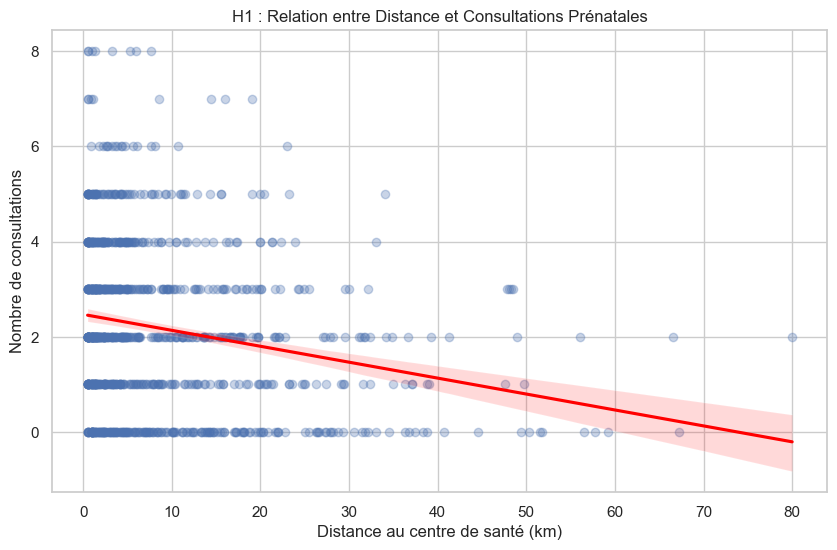

In [4]:
correlation, p_value = stats.pearsonr(df_h1['distance_centre_sante_km'], df_h1['nb_consultations_prenatales'])
print(f"Coefficient de corrélation (r) : {correlation:.4f}")
print(f"P-value : {p_value:.4e}")

plt.figure(figsize=(10, 6))
sns.regplot(data=df_h1, x='distance_centre_sante_km', y='nb_consultations_prenatales', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('H1 : Relation entre Distance et Consultations Prénatales')
plt.xlabel('Distance au centre de santé (km)')
plt.ylabel('Nombre de consultations')
plt.show()

**Justification du résultat :**
Le coefficient $r = -0.2049$ indique une corrélation négative faible mais réelle. 
La $p-value < 0.05$ (2.91e-11) nous permet de **rejeter $H_0$**. 
**Conclusion :** L'hypothèse est confirmée. La distance impacte négativement la fréquence des consultations.

### 4. Hypothèse 2 : Niveau d'Instruction vs Satisfaction

#### Énoncé de l'Hypothèse
On suppose que les patientes ayant un niveau d'instruction plus élevé ont des attentes plus fortes, ce qui pourrait se traduire par une satisfaction plus faible vis-à-vis des services actuels.

#### Formalisation Mathématique
- $H_0$ : $\mu_{Aucun} = \mu_{Primaire} = \mu_{Secondaire} = \mu_{Supérieur}$ (Les moyennes de satisfaction sont égales entre les groupes).
- $H_1$ : Au moins une moyenne est différente (Le niveau d'instruction influence la satisfaction).

#### Résolution et Analyse

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5704\866695485.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='niveau_instruction', y='satisfaction_service_sante_1a5', order=order, palette='viridis')


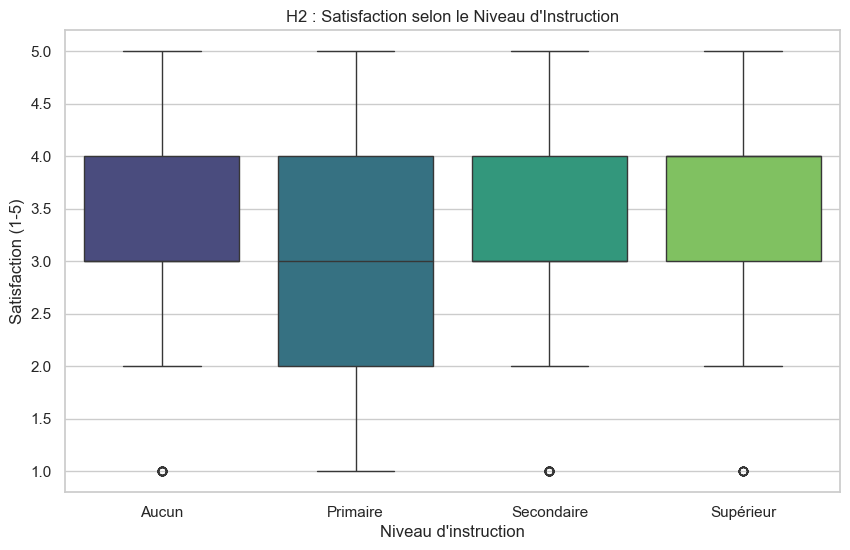

Statistique H de Kruskal-Wallis : 3.9355
P-value : 2.6851e-01


In [5]:
order = ['Aucun', 'Primaire', 'Secondaire', 'Supérieur']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='niveau_instruction', y='satisfaction_service_sante_1a5', order=order, palette='viridis')
plt.title('H2 : Satisfaction selon le Niveau d\'Instruction')
plt.xlabel('Niveau d\'instruction')
plt.ylabel('Satisfaction (1-5)')
plt.show()

# Test statistique de Kruskal-Wallis (adapté pour les données ordinales de satisfaction)
groups = [df[df['niveau_instruction'] == level]['satisfaction_service_sante_1a5'] for level in order]
h_stat, p_val_h = stats.kruskal(*groups)
print(f"Statistique H de Kruskal-Wallis : {h_stat:.4f}")
print(f"P-value : {p_val_h:.4e}")

**Justification du résultat :**
La $p-value$ (0.268) est supérieure au seuil de significativité de 0.05. 
**Conclusion :** Nous ne pouvons pas rejeter $H_0$. Il n'existe pas de preuve statistique que le niveau d'instruction affecte la satisfaction dans ce dataset.

Ce résultat peut s'expliquer par le fait que dans ce contexte, même les patients instruits n'ont pas d'alternative — ils utilisent les mêmes structures défaillantes et ont développé des attentes similaires.

### 5. Conclusion et Recommandations
1. **Accessibilité physique** : La distance étant un frein majeur, les politiques publiques devraient se concentrer sur le rapprochement des soins (postes de santé avancés).
2. **Équité de service** : Puisque l'instruction ne change pas la satisfaction, cela suggère que le service est perçu de manière équitable ou que les attentes sont similaires entre les classes sociales étudiées ici.